In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Illustration 10.2-1 &mdash; a whole phase diagram from one azeotropic point

**Illustration 10.2-1** and its two figures, for benzene / cyclohexane at 77.6 °C.

This is the most economical calculation in the chapter. A single measured azeotrope
&mdash; one composition, one temperature, one pressure &mdash; is enough to fix both
constants of a two-parameter activity coefficient model, and from there the entire
pressure-composition diagram follows.

The reason it works is that **an azeotrope is a thermodynamic constraint, not just a
data point**. At an azeotrope $x_i = y_i$, so the equilibrium relation
$x_i\gamma_iP_i^{\rm vap} = y_iP$ collapses to

$$\gamma_i = \frac{P}{P_i^{\rm vap}}$$

Two species, so two activity coefficients, so two constants. Nothing is fitted and nothing
is iterated; it is exact algebra on one measurement.

Part (b) then does the same system a completely different way &mdash; **predicting** the
activity coefficients from pure-component properties alone, with no reference to the
azeotrope or to any mixture measurement. That the two agree is the illustration's point.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo.vle import GammaPhi, TabulatedPsat, pxy, azeotrope
from thermo.vle_chart import pxy_chart
from thermo.activity_models import VanLaar, RegularSolution
from thermo.charts import use_book_style
use_book_style()

T = 273.15 + 77.6
P_az, x_az = 1.013, 0.525          # the measured azeotrope, bar and mole fraction benzene
Pvap_B, Pvap_C = 0.993, 0.980      # benzene, cyclohexane, at 77.6 C (bar)

## (a) Two constants from one point

The activity coefficients at the azeotropic composition are read straight off, then
Eq. 9.5-10 inverts the van Laar model for its two constants. `VanLaar.from_single_point`
is that inversion.

In [3]:
gB_az, gC_az = P_az / Pvap_B, P_az / Pvap_C
print(f"at the azeotrope, x_B = {x_az}:  gamma_B = {gB_az:.3f}, gamma_C = {gC_az:.3f}"
      f"   (book: 1.020, 1.034)")

vl = VanLaar.from_single_point(x_az, gB_az, gC_az)
print(f"van Laar constants:  alpha = {vl.alpha:.4f}, beta = {vl.beta:.4f}   (book: 0.125, 0.0919)")

at the azeotrope, x_B = 0.525:  gamma_B = 1.020, gamma_C = 1.034   (book: 1.020, 1.034)
van Laar constants:  alpha = 0.1249, beta = 0.0919   (book: 0.125, 0.0919)


It is worth pausing on how sensitive this is. The two constants come from two numbers
read to three figures; `VanLaar.from_single_point`'s own docstring warns that reading the
smoothed curve 0.2 % differently moves the constants by several percent. That is the price
of getting a model out of one measurement, and it is why part (b)'s independent route
matters.

## The whole diagram from those two constants

With $\gamma_B(x)$ and $\gamma_C(x)$ in hand, the total pressure and the vapor composition
follow at every liquid composition &mdash; the illustration's Eqs. (ii) and (iii), which
are just the bubble-point calculation. `GammaPhi` does it directly.

The vapor pressures here are **single measured numbers at one temperature**, not
correlations, so `TabulatedPsat` is the right carrier: it holds a constant and refuses to
supply a boiling point, which keeps an isothermal illustration from silently being asked
an isobaric question.

In [4]:
mix = GammaPhi([TabulatedPsat(Pvap_B * 1e5), TabulatedPsat(Pvap_C * 1e5)], vl,
               names=["benzene", "cyclohexane"])
rs = RegularSolution.from_book_names(["benzene", "cyclohexane"])

book = {0.0:(1.13,1.00,0.0,0.980,1.14,1.00), 0.1:(1.10,1.00,0.110,0.992,1.11,1.00),
        0.2:(1.07,1.01,0.212,1.001,1.09,1.00), 0.3:(1.05,1.01,0.311,1.006,1.07,1.01),
        0.4:(1.03,1.02,0.406,1.012,1.06,1.02), 0.5:(1.02,1.03,0.501,1.013,1.04,1.03),
        0.525:(1.02,1.03,0.525,1.013,1.04,1.04), 0.6:(1.01,1.04,0.596,1.010,1.03,1.05),
        0.7:(1.01,1.05,0.693,1.006,1.02,1.07), 0.8:(1.00,1.07,0.792,1.005,1.01,1.10),
        0.9:(1.00,1.08,0.894,1.000,1.00,1.13), 1.0:(1.00,1.10,1.0,0.993,1.00,1.17)}

print("           van Laar (correlated)              regular solution (predicted)")
print("   xB    gB     gC      yB      P(bar)          gB     gC")
for x in sorted(book):
    xx = [min(max(x,1e-12),1-1e-12), min(max(1-x,1e-12),1-1e-12)]
    P, y = mix.bubble_pressure(xx, T)
    g = mix.gamma(xx, T); gr = rs.gamma(xx, T)
    b = book[x]
    print(f"  {x:.3f}  {g[0]:.2f}/{b[0]:.2f}  {g[1]:.2f}/{b[1]:.2f}  "
          f"{y[0]:.3f}/{b[2]:.3f}  {P/1e5:.3f}/{b[3]:.3f}      "
          f"{gr[0]:.2f}/{b[4]:.2f}  {gr[1]:.2f}/{b[5]:.2f}")

           van Laar (correlated)              regular solution (predicted)
   xB    gB     gC      yB      P(bar)          gB     gC
  0.000  1.13/1.13  1.00/1.00  0.000/0.000  0.980/0.980      1.14/1.14  1.00/1.00
  0.100  1.10/1.10  1.00/1.00  0.110/0.110  0.993/0.992      1.11/1.11  1.00/1.00
  0.200  1.07/1.07  1.01/1.01  0.213/0.212  1.002/1.001      1.09/1.09  1.00/1.00
  0.300  1.05/1.05  1.01/1.01  0.311/0.311  1.008/1.006      1.07/1.07  1.01/1.01
  0.400  1.03/1.03  1.02/1.02  0.406/0.406  1.011/1.012      1.05/1.06  1.02/1.02
  0.500  1.02/1.02  1.03/1.03  0.501/0.501  1.013/1.013      1.04/1.04  1.03/1.03
  0.525  1.02/1.02  1.03/1.03  0.525/0.525  1.013/1.013      1.04/1.04  1.04/1.04
  0.600  1.01/1.01  1.04/1.04  0.596/0.596  1.012/1.010      1.03/1.03  1.05/1.05
  0.700  1.01/1.01  1.05/1.05  0.693/0.693  1.010/1.006      1.02/1.02  1.07/1.07
  0.800  1.00/1.00  1.07/1.07  0.792/0.792  1.006/1.005      1.01/1.01  1.10/1.10
  0.900  1.00/1.00  1.08/1.08  0.894/0.894  1.0

Every printed value reproduces &mdash; both models, all four columns &mdash; **with one
exception, at $x_B = 0.7$, where the printed pressure is wrong.**

The illustration prints $P = 1.006$ bar there. Its own van Laar constants give
**1.010**, and the discrepancy is too large for rounding. The printed vapor composition
settles which number is at fault: $y_B = 0.693$ is exactly what $P = 1.010$ implies
(0.6931), while $P = 1.006$ would require $y_B = 0.696$. So the $y$ column is right and
the $P$ entry is not.

The likely mechanism is visible one row down: **1.006 is the pressure that belongs to
$x_B = 0.8$**, so the value appears to have been copied into the wrong row. Filed as
erratum E16.

Note also the azeotrope row: the pressure returns 1.013 bar at $x_B = 0.525$, which it
must, because that point is what the constants were built from. It is the one row that is
a tautology; the others are not, which is why the $x_B = 0.7$ failure is meaningful.

In [5]:
x_bad = 0.7
g = vl.gamma([x_bad, 1 - x_bad], T)
P_bad = x_bad*g[0]*Pvap_B + (1 - x_bad)*g[1]*Pvap_C
print(f"x_B = 0.7:  P = {P_bad:.4f} bar   printed 1.006")
print(f"            y_B from P = {P_bad:.3f}:  {x_bad*g[0]*Pvap_B/P_bad:.4f}   printed 0.693  <- agrees")
print(f"            y_B from P = 1.006     :  {x_bad*g[0]*Pvap_B/1.006:.4f}   printed 0.693  <- does not")
x8 = 0.8
g8 = vl.gamma([x8, 1-x8], T)
print(f"\nand the x_B = 0.8 row:  P = {x8*g8[0]*Pvap_B + (1-x8)*g8[1]*Pvap_C:.4f}"
      f"  -- which is where 1.006 belongs")

x_B = 0.7:  P = 1.0101 bar   printed 1.006
            y_B from P = 1.010:  0.6931   printed 0.693  <- agrees
            y_B from P = 1.006     :  0.6959   printed 0.693  <- does not

and the x_B = 0.8 row:  P = 1.0061  -- which is where 1.006 belongs


## (b) The same mixture predicted, with no mixture data at all

Regular solution theory needs only a molar volume and a solubility parameter per species,
both pure-component properties from Table 9.6-1. It never sees the azeotrope.

Benzene and cyclohexane are both nonpolar, which is the condition for the theory to apply
&mdash; and the reason this system was chosen. The predicted activity coefficients above
sit within about 0.01 of the correlated ones across the whole range, and the two disagree
most at the pure ends, where each model is extrapolating hardest.

In [6]:
xg = np.linspace(1e-9, 1-1e-9, 400)
g_vl = np.array([vl.gamma([x, 1-x], T) for x in xg])
g_rs = np.array([rs.gamma([x, 1-x], T) for x in xg])
print(f"largest disagreement in gamma_B: {np.abs(g_vl[:,0]-g_rs[:,0]).max():.3f}"
      f"  at x_B = {xg[np.argmax(np.abs(g_vl[:,0]-g_rs[:,0]))]:.2f}")
print(f"largest disagreement in gamma_C: {np.abs(g_vl[:,1]-g_rs[:,1]).max():.3f}"
      f"  at x_B = {xg[np.argmax(np.abs(g_vl[:,1]-g_rs[:,1]))]:.2f}")

az = azeotrope(mix, T=T)
print(f"\nazeotrope recovered from the model: x_B = {az[0]:.4f}, P = {az[1]/1e5:.4f} bar"
      f"   (input: {x_az}, {P_az})")

largest disagreement in gamma_B: 0.021  at x_B = 0.29
largest disagreement in gamma_C: 0.073  at x_B = 1.00

azeotrope recovered from the model: x_B = 0.5250, P = 1.0130 bar   (input: 0.525, 1.013)


## Figure 1 &mdash; the activity coefficients

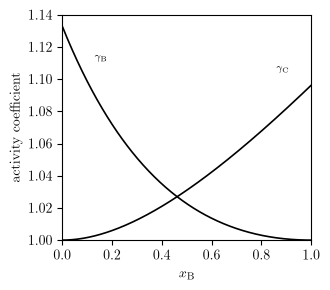

In [7]:
fig, ax = plt.subplots(figsize=(3.4, 3.0))
ax.plot(xg, g_vl[:, 0], "-", color="k", lw=1.2)
ax.plot(xg, g_vl[:, 1], "-", color="k", lw=1.2)
# Each label sits ABOVE its own curve, in the open wedge between that curve and the
# top of the frame. At x = 0.13 gamma_B is 1.0901 and at x = 0.86 gamma_C is 1.0760,
# so the previous 1.088 and 1.075 put both labels exactly ON the lines they name
# (author, 2026-08-15).
ax.text(0.13, 1.112, r"$\gamma_{\rm B}$", fontsize=7)
ax.text(0.86, 1.105, r"$\gamma_{\rm C}$", fontsize=7)
ax.set_xlabel(r"$x_{\rm B}$"); ax.set_ylabel("activity coefficient")
ax.set_xlim(0, 1); ax.set_ylim(1.00, 1.14)
fig.tight_layout()

## Figure 2 &mdash; total pressure against both compositions

Solid against the liquid composition, dashed against the vapor. The two curves cross at
the azeotrope, which is the graphical statement of $x = y$ there.

This is the one envelope in the chapter drawn with a **dashed dew line**. The whole
diagram spans 0.98 to 1.02 bar, so the two curves nearly touch and there is no room for
the `Liquid` / `Vapor` region labels that identify them elsewhere; the 5e dashes the vapor
line here for the same reason.

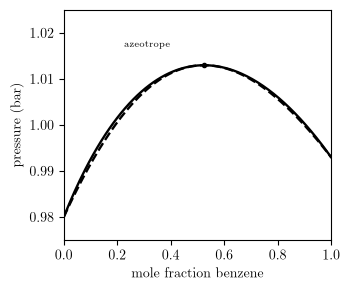

In [8]:
x1, y1, P = pxy(mix, T)

fig, ax = plt.subplots(figsize=(3.6, 3.0))
pxy_chart(ax, x1, y1, P, species="benzene", regions=False, dew_style="--")
ax.plot([x_az], [P_az], "o", color="k", ms=3)
ax.annotate("azeotrope", xy=(x_az, P_az), xytext=(x_az - 0.30, P_az + 0.004), fontsize=6.5)
ax.set_ylim(0.975, 1.025)
fig.tight_layout()

## What the illustration is really showing

Two routes to the same curve, from completely different inputs:

| | needs | gets |
|---|---|---|
| van Laar | **one mixture measurement** (the azeotrope) | the diagram, exactly through that point |
| regular solution | **two pure-component numbers per species**, no mixture data | the same diagram to within 0.01 in $\gamma$ |

That agreement is not general &mdash; it holds here because both species are nonpolar and
similar in size, which is exactly regular solution theory's domain. Chapter 9's
benzene / 2,2,4-trimethyl pentane comparison is the counter-example: there the regular
solution prediction has the right sign and about twice the magnitude.

The practical reading: if you have *one* azeotrope, you can correlate. If you have *no*
mixture data at all and the species are nonpolar, you can still predict.

## Print art

In [9]:
# --- Print art: Illustration 10.2-1, Figures 1 and 2 -----------------------
# Stage as deliverables/figures/print-bw/ch10/c10uf002.pdf and c10uf003.pdf
#
# Figure 2 keeps the 5e's solid-liquid / dashed-vapor convention -- the envelope
# spans 0.04 bar and the curves nearly touch, so the region labels used on every
# other envelope in this chapter will not fit and would not disambiguate anyway.
import os
os.makedirs("pdf", exist_ok=True)

f, a = plt.subplots(figsize=(3.4, 3.0))
a.plot(xg, g_vl[:, 0], "-", color="k", lw=1.2)
a.plot(xg, g_vl[:, 1], "-", color="k", lw=1.2)
# Each label sits ABOVE its own curve, in the open wedge between that curve and the
# top of the frame. At x = 0.13 gamma_B is 1.0901 and at x = 0.86 gamma_C is 1.0760,
# so the previous 1.088 and 1.075 put both labels exactly ON the lines they name
# (author, 2026-08-15).
a.text(0.13, 1.112, r"$\gamma_{\rm B}$", fontsize=7)
a.text(0.86, 1.105, r"$\gamma_{\rm C}$", fontsize=7)
a.set_xlabel(r"$x_{\rm B}$"); a.set_ylabel("activity coefficient")
a.set_xlim(0, 1); a.set_ylim(1.00, 1.14)
f.tight_layout(); f.savefig("pdf/Illustration_10.2-1_fig1.pdf", dpi=300, bbox_inches="tight")
plt.close(f)

f, a = plt.subplots(figsize=(3.6, 3.0))
pxy_chart(a, x1, y1, P, species="benzene", regions=False, dew_style="--")
a.plot([x_az], [P_az], "o", color="k", ms=3)
a.set_ylim(0.975, 1.025)
f.tight_layout(); f.savefig("pdf/Illustration_10.2-1_fig2.pdf", dpi=300, bbox_inches="tight")
plt.close(f)
print("wrote pdf/Illustration_10.2-1_fig1.pdf and _fig2.pdf")

wrote pdf/Illustration_10.2-1_fig1.pdf and _fig2.pdf


## Your turn

1. The two constants came from activity coefficients read to three figures. Change
   $P_B^{\rm vap}$ from 0.993 to 0.990 bar &mdash; a third of a percent &mdash; and see
   how far $\alpha$, $\beta$ and the predicted pure-end activity coefficients move. Is a
   model built from one point worth three figures of confidence?
2. The illustration says benzene and cyclohexane "will be very difficult to separate by
   distillation." Build the $x$-$y$ diagram and say why, in one sentence, using the
   distance from the $x = y$ line.
3. Regular solution theory needs no mixture data. Try it on ethyl acetate / benzene from
   Illustration 10.2-2, where one species is polar, and compare with the van Laar
   constants that illustration uses. What does the failure look like?